In [18]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from sympy.codegen.numpy_nodes import minimum

In [17]:
# read the pickle file
with open('../tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_positions = pickle.load(f)

In [21]:
ball_positions = [x.get(1,[]) for x in ball_positions]
df_ball_positions = pd.DataFrame(
    ball_positions,
    columns=['x1','y1','x2','y2']
)

df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()

In [25]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2']) / 2
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()

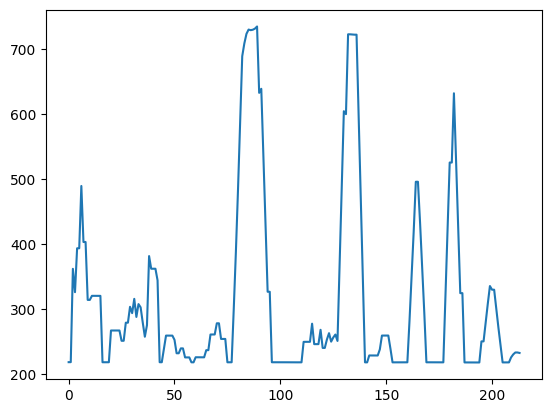

In [28]:
plt.plot(df_ball_positions['mid_y_rolling_mean'])

In [34]:
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()

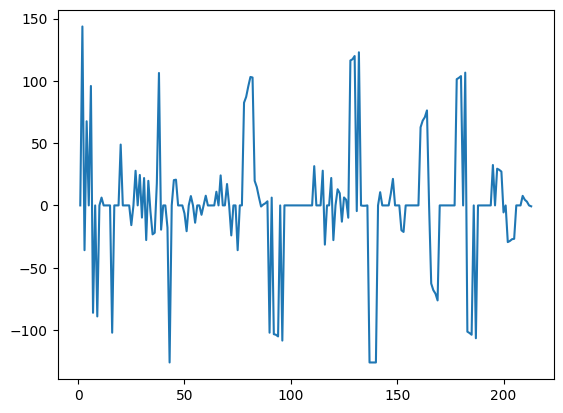

In [35]:
plt.plot(df_ball_positions['delta_y'])

In [36]:
df_ball_positions['ball_hit']=0

In [58]:

minimum_change_frames_for_hit = 25
for i in range(1,len(df_ball_positions)- int(minimum_change_frames_for_hit*1.2) ):
    negative_position_change = df_ball_positions['delta_y'].iloc[i] >0 and df_ball_positions['delta_y'].iloc[i+1] <0
    positive_position_change = df_ball_positions['delta_y'].iloc[i] <0 and df_ball_positions['delta_y'].iloc[i+1] >0

    if negative_position_change or positive_position_change:
        change_count = 0
        for change_frame in range(i+1, i+int(minimum_change_frames_for_hit*1.2)+1):
            negative_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] >0 and df_ball_positions['delta_y'].iloc[change_frame] <0
            positive_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] <0 and df_ball_positions['delta_y'].iloc[change_frame] >0

            if negative_position_change and negative_position_change_following_frame:
                change_count+=1
            elif positive_position_change and positive_position_change_following_frame:
                change_count+=1

        if change_count>minimum_change_frames_for_hit-1:
            df_ball_positions['ball_hit'].iloc[i] = 1

frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit']==1].index.tolist()

In [60]:
df_ball_positions[df_ball_positions['ball_hit']==0]

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean,delta_y,ball_hit
0,146.956192,200.098160,169.976318,236.644913,218.371536,218.371536,NaN,0
1,147.078293,200.237961,170.004608,236.573685,218.405823,218.388680,0.017143,0
2,875.744385,630.606445,900.128174,668.063232,649.334839,362.037399,143.648720,0
3,146.934464,200.150253,170.074371,236.407242,218.278748,326.097736,-35.939663,0
4,848.821350,642.436279,872.884338,685.312622,663.874451,393.653079,67.555343,0
...,...,...,...,...,...,...,...,...
209,1180.108521,233.584351,1205.571899,279.184570,256.384460,225.703178,7.673108,0
210,1173.792480,216.061172,1203.143555,265.594025,240.827599,230.260208,4.557030,0
211,1176.734375,209.584412,1202.970093,256.740021,233.162216,233.285306,3.025098,0
212,147.140640,199.760376,170.285812,236.279526,218.019951,233.278947,-0.006358,0


In [56]:

df_ball_positions[df_ball_positions['ball_hit']==0]

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean,delta_y,ball_hit
0,146.956192,200.098160,169.976318,236.644913,218.371536,218.371536,NaN,0
1,147.078293,200.237961,170.004608,236.573685,218.405823,218.388680,0.017143,0
2,875.744385,630.606445,900.128174,668.063232,649.334839,362.037399,143.648720,0
3,146.934464,200.150253,170.074371,236.407242,218.278748,326.097736,-35.939663,0
4,848.821350,642.436279,872.884338,685.312622,663.874451,393.653079,67.555343,0
...,...,...,...,...,...,...,...,...
209,1180.108521,233.584351,1205.571899,279.184570,256.384460,225.703178,7.673108,0
210,1173.792480,216.061172,1203.143555,265.594025,240.827599,230.260208,4.557030,0
211,1176.734375,209.584412,1202.970093,256.740021,233.162216,233.285306,3.025098,0
212,147.140640,199.760376,170.285812,236.279526,218.019951,233.278947,-0.006358,0
